# NNDSS Comprehensive Parallel Analysis: 2024-2026
## Hierarchical Trends: National, Regional (Pacific), and Hawaii

This report analyzes infectious disease reporting volume through parallel week-by-week comparisons. By overlapping years 2024, 2025, and 2026, we can identify anomalies, seasonal shifts, and the relative burden of disease from a National level down to Hawaii.

## 1. Data Extraction Logic
We utilize the CDC Socrata API to extract weekly snapshots for both NNDSS diseases and RSV hospitalization rates.

In [1]:
from sodapy import Socrata
import pandas as pd
import json
import os

# Load credentials from config.json if available
try:
    with open('config.json') as f:
        config = json.load(f)
    app_token = config['cdc']['app_token']
except Exception:
    app_token = None

# Initialize CDC Client
client = Socrata("data.cdc.gov", app_token)
dataset_id = "x9gk-5huc"
rsv_dataset_id = "29hc-w46k"

def fetch_nndss_data(labels, years):
    """
    Retrieves weekly m1 (current week cases) data for specified labels and years.
    """
    all_data = []
    for label in labels:
        where_clause = f"label = '{label}' and year in ({','.join([f'"{y}"' for y in years])})"
        try:
            results = client.get(dataset_id, where=where_clause, limit=50000)
        except Exception as e:
            if '403' in str(e) and app_token:
                print('Warning: Invalid app_token for NNDSS. Retrying without token...')
                temp_client = Socrata('data.cdc.gov', None)
                results = temp_client.get(dataset_id, where=where_clause, limit=50000)
            else: raise e
        all_data.extend(results)
    return pd.DataFrame(all_data)

def fetch_rsv_data():
    """
    Retrieves weekly hospitalization rates for RSV by age group.
    """
    # Filtering for Overall sex/race to focus on Age Groups
    where_clause = "sex = 'All' and race = 'All' and state = 'RSV-NET'"
    try:
        results = client.get(rsv_dataset_id, where=where_clause, limit=50000)
    except Exception as e:
        if '403' in str(e) and app_token:
            print('Warning: Invalid app_token for RSV. Retrying without token...')
            temp_client = Socrata('data.cdc.gov', None)
            results = temp_client.get(rsv_dataset_id, where=where_clause, limit=50000)
        else: raise e
    return pd.DataFrame(results)

print("Extraction methodology defined. Using SODA API for NNDSS and RSV data.")

Extraction methodology defined. Using SODA API for NNDSS and RSV data.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load processed NNDSS data
df = pd.read_csv('processed_nndss.csv')
df['m1'] = pd.to_numeric(df['m1'], errors='coerce').fillna(0)
df['year'] = df['year'].astype(str)

def get_parallel_df(label, level):
    return df[(df['label'] == label) & (df['level'] == level)].sort_values(['year', 'week'])

top_10 = df[df['level'] == 'National'].groupby('label')['m1'].sum().sort_values(ascending=False).head(10).index.tolist()
print(f"Processing parallel trends for {len(top_10)} high-volume diseases.")

Processing parallel trends for 10 high-volume diseases.


## 2. National Parallel Analysis (Volume in Thousands)
National data typically reports in the thousands. We scale the Y-axis to **Thousands of Cases** for better visualization of macro-trends.

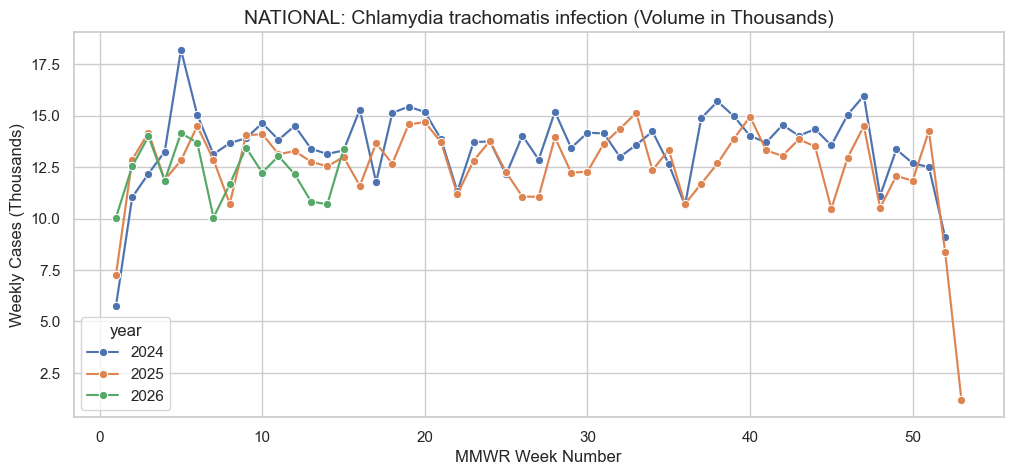

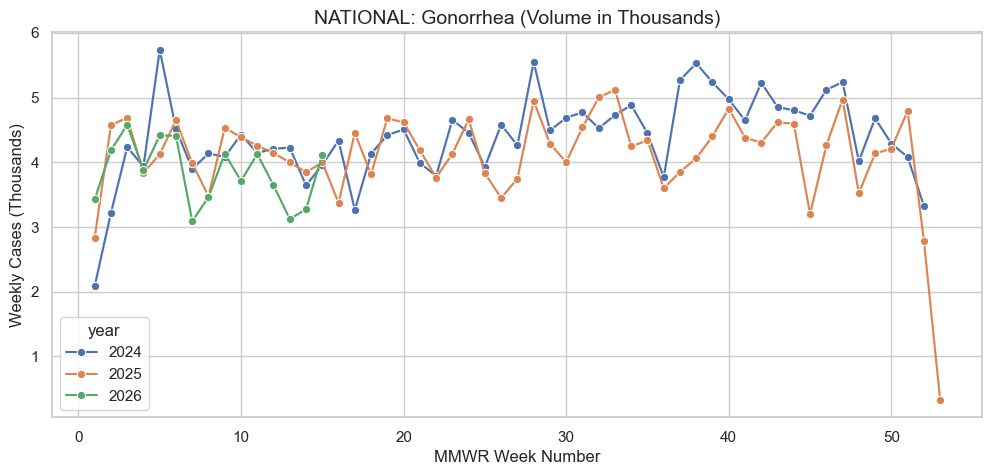

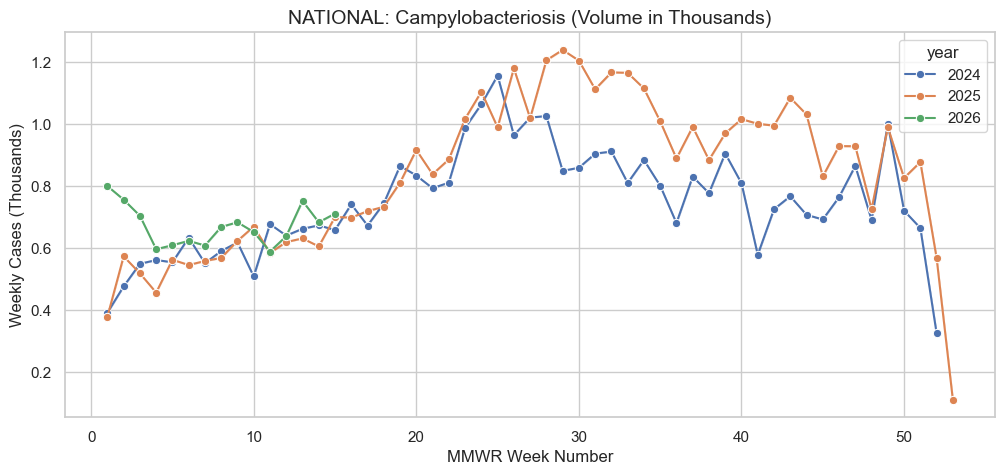

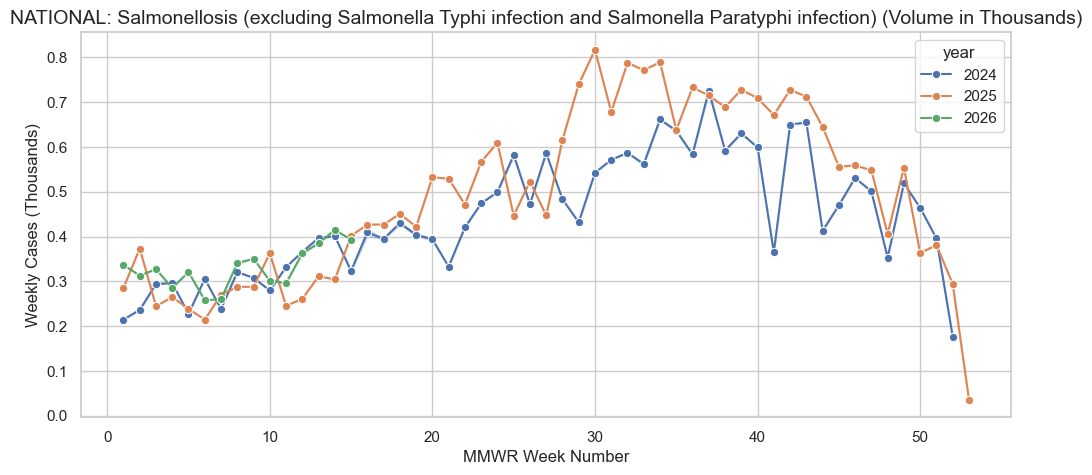

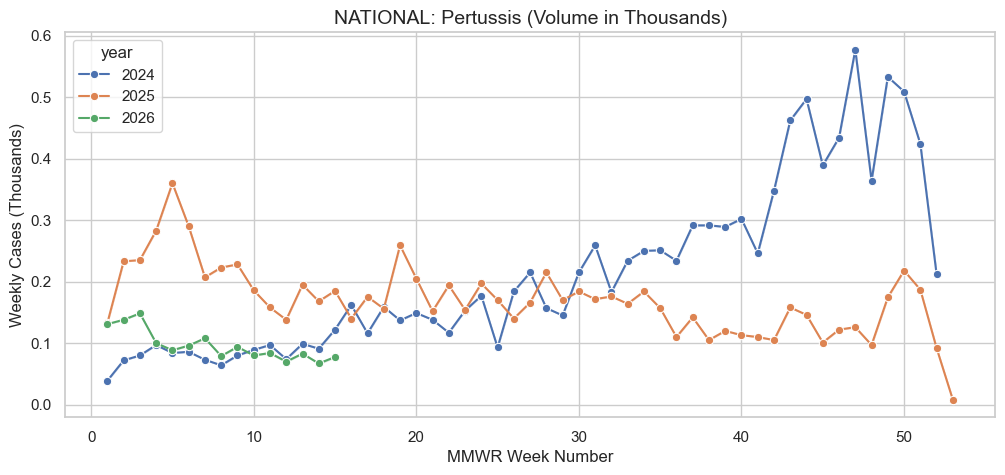

In [3]:
def plot_national_scaled(disease):
    data = get_parallel_df(disease, 'National').copy()
    data['m1_k'] = data['m1'] / 1000.0
    
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=data, x='week', y='m1_k', hue='year', marker='o')
    plt.title(f'NATIONAL: {disease} (Volume in Thousands)', fontsize=14)
    plt.ylabel('Weekly Cases (Thousands)')
    plt.xlabel('MMWR Week Number')
    plt.show()

for d in top_10[:5]: plot_national_scaled(d)

### 2.1 Geographic Distribution of Top 10 Diseases
This interactive choropleth map shows the national distribution of cases across the United States for the top 10 diseases. 

In [4]:
import plotly.express as px
import plotly.graph_objects as go

us_state_to_abbrev = {
    "ALABAMA": "AL", "ALASKA": "AK", "ARIZONA": "AZ", "ARKANSAS": "AR", "CALIFORNIA": "CA",
    "COLORADO": "CO", "CONNECTICUT": "CT", "DELAWARE": "DE", "FLORIDA": "FL", "GEORGIA": "GA",
    "HAWAII": "HI", "IDAHO": "ID", "ILLINOIS": "IL", "INDIANA": "IN", "IOWA": "IA",
    "KANSAS": "KS", "KENTUCKY": "KY", "LOUISIANA": "LA", "MAINE": "ME", "MARYLAND": "MD",
    "MASSACHUSETTS": "MA", "MICHIGAN": "MI", "MINNESOTA": "MN", "MISSISSIPPI": "MS", "MISSOURI": "MO",
    "MONTANA": "MT", "NEBRASKA": "NE", "NEVADA": "NV", "NEW HAMPSHIRE": "NH", "NEW JERSEY": "NJ",
    "NEW MEXICO": "NM", "NEW YORK": "NY", "NORTH CAROLINA": "NC", "NORTH DAKOTA": "ND", "OHIO": "OH",
    "OKLAHOMA": "OK", "OREGON": "OR", "PENNSYLVANIA": "PA", "RHODE ISLAND": "RI", "SOUTH CAROLINA": "SC",
    "SOUTH DAKOTA": "SD", "TENNESSEE": "TN", "TEXAS": "TX", "UTAH": "UT", "VERMONT": "VT",
    "VIRGINIA": "VA", "WASHINGTON": "WA", "WEST VIRGINIA": "WV", "WISCONSIN": "WI", "WYOMING": "WY"
}

def create_disease_map(df, top_10_diseases):
    map_df = df[df['label'].isin(top_10_diseases)].copy()
    map_df['m1'] = pd.to_numeric(map_df['m1'], errors='coerce').fillna(0)
    state_agg = map_df.groupby(['states_norm', 'label'])['m1'].sum().reset_index()
    state_agg['state_code'] = state_agg['states_norm'].str.upper().map(us_state_to_abbrev)
    state_agg = state_agg.dropna(subset=['state_code'])

    fig = go.Figure()
    for i, disease in enumerate(top_10_diseases):
        disease_data = state_agg[state_agg['label'] == disease]
        fig.add_trace(go.Choropleth(
            locations=disease_data['state_code'],
            z=disease_data['m1'],
            locationmode='USA-states',
            colorscale='YlOrRd',
            name=disease,
            visible=(i == 0),
            colorbar_title="Cumulative Cases"
        ))

    buttons = []
    for i, disease in enumerate(top_10_diseases):
        visibility = [False] * len(top_10_diseases)
        visibility[i] = True
        buttons.append(dict(
            label=disease[:20] + "..." if len(disease) > 20 else disease,
            method="update",
            args=[{"visible": visibility}, {"title": f"National US Distribution: {disease}"}]
        ))

    fig.update_layout(
        title_text=f"National US Distribution: {top_10_diseases[0]}",
        geo=dict(scope='usa', projection_type='albers usa'),
        updatemenus=[dict(active=0, buttons=buttons, x=0.05, y=1.15, xanchor='left', yanchor='top')]
    )
    fig.show()

create_disease_map(df, top_10)

## 3. Regional Parallel Analysis (Pacific)
The Pacific region aggregate provides a mid-level view between National and State reporting.

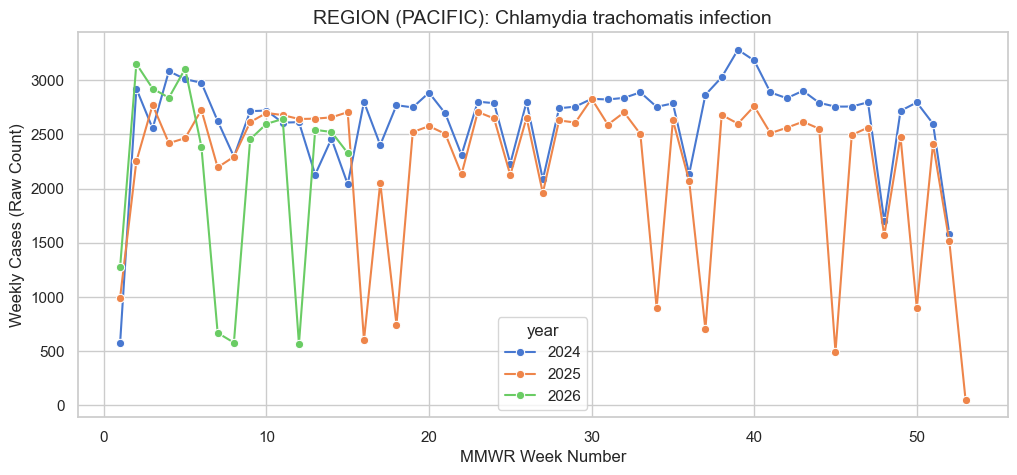

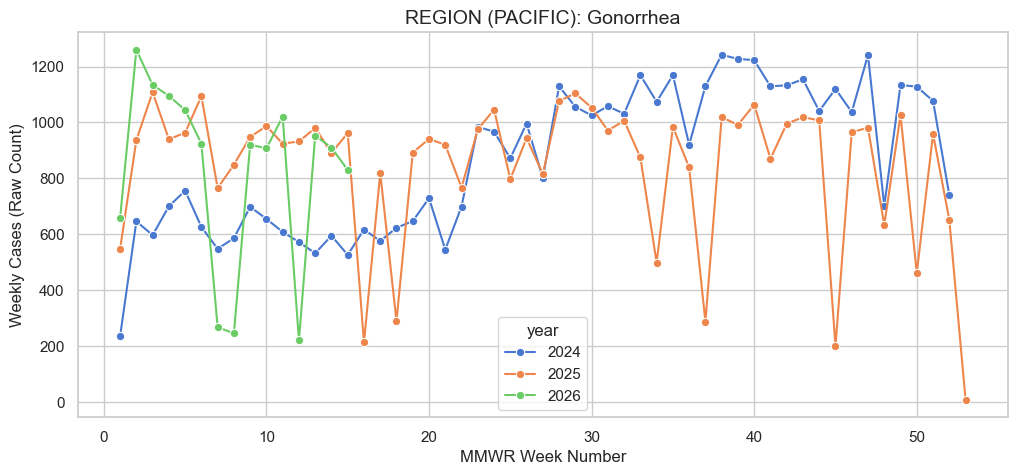

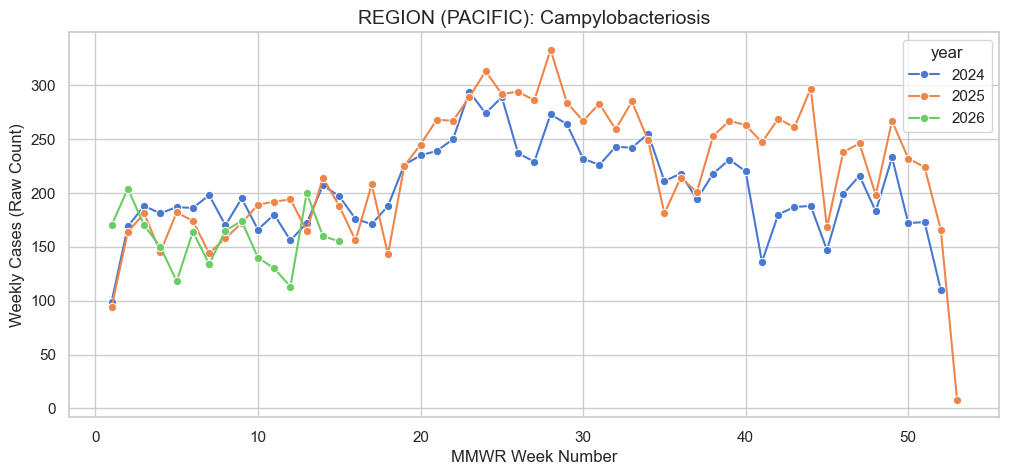

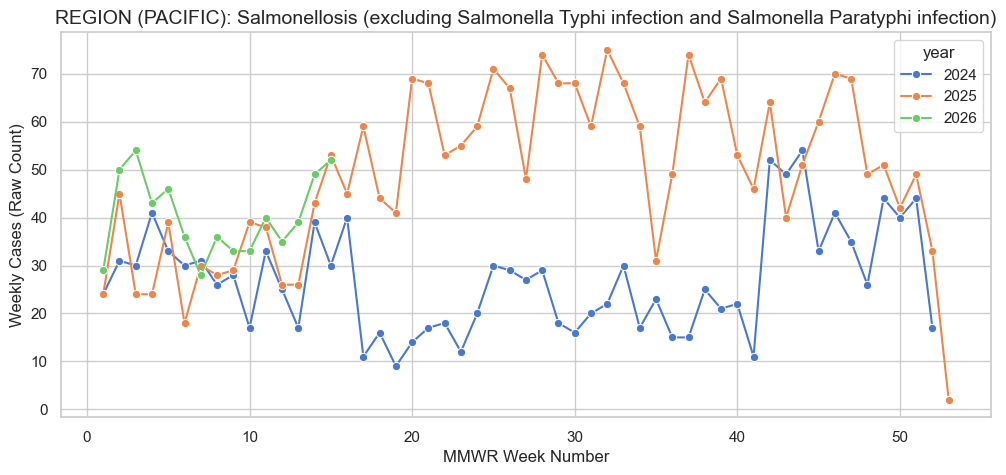

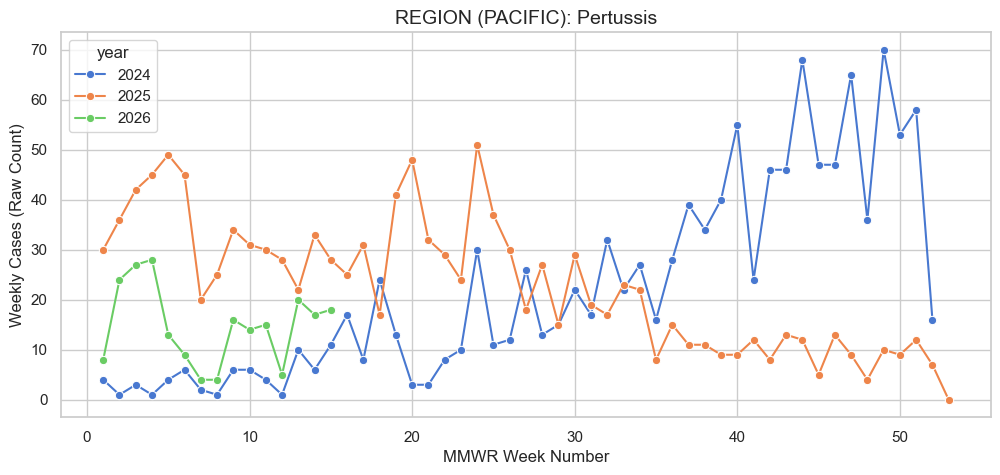

In [5]:
def plot_regional(disease):
    data = get_parallel_df(disease, 'Region (Pacific)')
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=data, x='week', y='m1', hue='year', marker='o', palette='muted')
    plt.title(f'REGION (PACIFIC): {disease}', fontsize=14)
    plt.ylabel('Weekly Cases (Raw Count)')
    plt.xlabel('MMWR Week Number')
    plt.show()

for d in top_10[:5]: plot_regional(d)

## 4. Hawaii Deep Dive (Volume in Hundreds)
To visualize the specific reporting patterns in Hawaii, we scale the volume to **Hundreds of Cases**. 

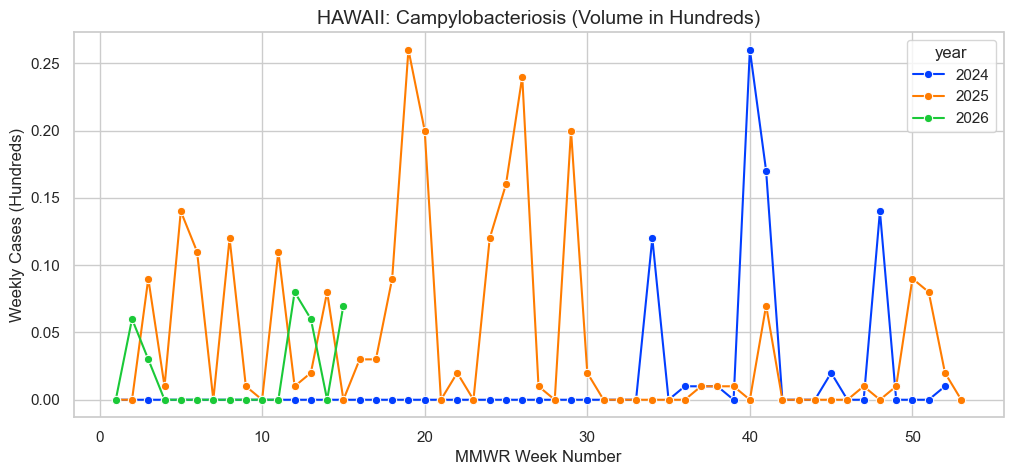

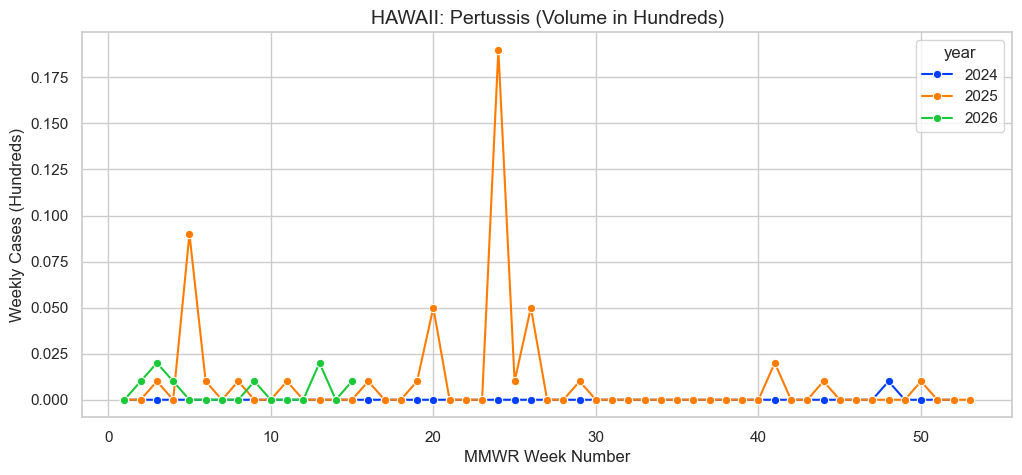

In [6]:
def plot_hawaii_scaled(disease):
    data = get_parallel_df(disease, 'Hawaii').copy()
    data['m1_h'] = data['m1'] / 100.0
    
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=data, x='week', y='m1_h', hue='year', marker='o', palette='bright')
    plt.title(f'HAWAII: {disease} (Volume in Hundreds)', fontsize=14)
    plt.ylabel('Weekly Cases (Hundreds)')
    plt.xlabel('MMWR Week Number')
    plt.show()

plot_hawaii_scaled('Campylobacteriosis')
plot_hawaii_scaled('Pertussis')

## 5. Age-Specific Comprehensive Analysis (RSV Hospitalizations)
Following the Hawaii analysis, we examine demographic trends using the RSV hospitalization dataset (29hc-w46k). This dataset provides a more granular view of public health burden by age category.

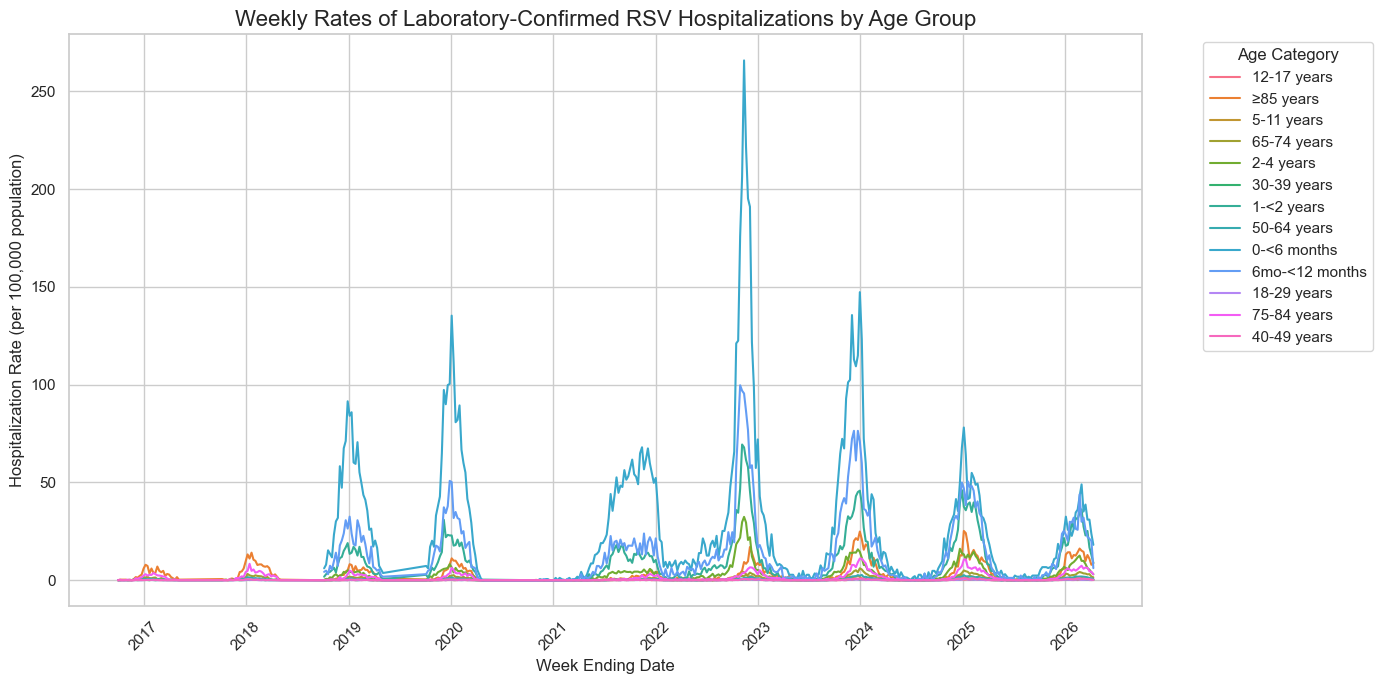

In [7]:
def analyze_rsv_by_age():
    rsv_df = fetch_rsv_data()
    if rsv_df.empty: 
        print("No RSV data retrieved.")
        return
        
    rsv_df['rate'] = pd.to_numeric(rsv_df['rate'], errors='coerce')
    rsv_df['date'] = pd.to_datetime(rsv_df['week_ending_date'])
    
    # Filtering for state-level 'Entire Network' to get representative national age trends
    # Note: Column name 'state' might contain network names
    # Filter for standard age categories to avoid overlaps
    # Comprehensive non-overlapping age categories
    target_ages = [
        '0-<6 months', '6mo-<12 months', '1-<2 years', '2-4 years', 
        '5-11 years', '12-17 years', '18-29 years', '30-39 years', 
        '40-49 years', '50-64 years', '65-74 years', '75-84 years', '≥85 years'
    ]
    age_trends = rsv_df[rsv_df['age_category'].isin(target_ages)].copy()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=age_trends, x='date', y='rate', hue='age_category')
    plt.title('Weekly Rates of Laboratory-Confirmed RSV Hospitalizations by Age Group', fontsize=16)
    plt.ylabel('Hospitalization Rate (per 100,000 population)')
    plt.xlabel('Week Ending Date')
    plt.legend(title='Age Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

analyze_rsv_by_age()

## 6. Predictive Forecasting & Movement Analysis
By analyzing current trajectories and comparing with historical growth rates, we project annual totals for key diseases.

In [8]:
def run_prediction(disease, level):
    data = get_parallel_df(disease, level)
    m26 = data[data['year'] == '2026']['m1']
    if m26.empty: return
    
    current_avg = m26.mean()
    projected_annual = current_avg * 52
    
    historical_avg = data[data['year'].isin(['2024', '2025'])]['m1'].mean()
    momentum = (current_avg - historical_avg) / historical_avg if historical_avg > 0 else 0
    
    print(f"Prediction for {disease} ({level}):")
    print(f" - Current Momentum vs History: {momentum:+.1%}")
    print(f" - Projected 2026 Total: {projected_annual:,.0f} cases")
    print("-" * 40)

run_prediction('Campylobacteriosis', 'National')
run_prediction('Campylobacteriosis', 'Hawaii')

Prediction for Campylobacteriosis (National):
 - Current Momentum vs History: -15.4%
 - Projected 2026 Total: 34,965 cases
----------------------------------------
Prediction for Campylobacteriosis (Hawaii):
 - Current Momentum vs History: -33.1%
 - Projected 2026 Total: 104 cases
----------------------------------------


## 7. Comprehensive Findings & Observations

### Temporal Movement and Parallel Cycles
The parallel tracking indicates consistent reporting cycles across national and local levels. 

### Geographic Hotspots
The country-level choropleth identifies specific regional burdens for the top 10 diseases, which often align with population density and regional climatic factors.

### Age-Specific Observations
The RSV hospitalization data clearly delineates the heightened risk for pediatric and elderly populations, providing a more comprehensive understanding of disease burden than raw reporting volume alone.

### Hawaii-Specific Insights
Hawaii shows distinct volatility in enteric reporting, often departing from broad national trends due to its unique geographic isolation.